Random Forest – Freight Cost Prediction

Project Objective:A customer asks:

"I want to ship one container from Mundra to Chennai."

The logistics team wants to know the estimated freight cost before booking.

Instead of manual estimation, we'll build a Random Forest model.

In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
df=pd.read_excel("/content/Freight_Cost_Prediction_md.xlsx")
df

,Shipment_ID,Booking_Date,Origin,Destination,Shipping_Line,Container_Type,Commodity,Weight_MT,Distance_KM,Fuel_Price,Transit_Days,Port_Congestion,Weather,Freight_Cost,Customer,Export_Country,Exchange_Rate,Insurance_Cost,Handling_Charges,Profit
0,SH00001,2024-01-16,Kandla,Hyderabad,Hapag-Lloyd,20FT,Chilli,20.79,1872,98.75,4,High,Storm,62025.0,Customer_041,Canada,86.76,4575.6,4088.07,9482.26
1,SH00002,2025-07-26,Kolkata,Jaipur,CMA CGM,20FT,Coriander,16.82,726,98.66,2,Low,Rain,37189.2,Customer_104,Australia,82.55,2124.8,1746.09,3408.39
2,SH00003,2025-08-15,Mumbai,Delhi ICD,Hapag-Lloyd,20FT,Green Cardamom,17.08,333,97.82,2,Low,Rain,32606.4,Customer_096,USA,81.07,1349.2,2440.80,4172.67
3,SH00004,2025-02-27,Kandla,Nagpur,Evergreen,40FT,Black Pepper,20.82,1139,101.18,4,Low,Clear,56547.6,Customer_113,Singapore,83.22,3110.8,1599.50,7143.67
4,SH00005,2024-08-17,Nava Sheva,Ahmedabad,COSCO,40FT,Turmeric,22.01,2668,99.05,6,Medium,Rain,79711.0,Customer_005,Germany,88.77,6216.4,4373.25,8936.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,SH04996,2024-02-08,Vizag,Lucknow,Evergreen,40FT,Turmeric,24.41,2546,86.91,7,High,Storm,83950.2,Customer_062,USA,88.56,6068.4,3317.97,10483.32
4996,SH04997,2025-02-18,Vizag,Ahmedabad,COSCO,20FT,Black Pepper,10.78,2240,93.43,6,Medium,Rain,51793.6,Customer_044,USA,81.01,4911.2,3524.21,5759.88
4997,SH04998,2025-09-30,Mundra,Delhi ICD,Maersk,40FT,Cumin,26.98,2298,92.49,6,Medium,Rain,78956.8,Customer_026,UAE,84.49,5675.2,4080.34,6515.77
4998,SH04999,2024-01-18,Kandla,Lucknow,COSCO,40FT,Coriander,23.66,560,91.64,3,Low,Clear,51010.8,Customer_003,UK,81.96,2066.4,1889.79,4407.18


In [ ]:
df.head()#

,Shipment_ID,Booking_Date,Origin,Destination,Shipping_Line,Container_Type,Commodity,Weight_MT,Distance_KM,Fuel_Price,Transit_Days,Port_Congestion,Weather,Freight_Cost,Customer,Export_Country,Exchange_Rate,Insurance_Cost,Handling_Charges,Profit
0,SH00001,2024-01-16,Kandla,Hyderabad,Hapag-Lloyd,20FT,Chilli,20.79,1872,98.75,4,High,Storm,62025.0,Customer_041,Canada,86.76,4575.6,4088.07,9482.26
1,SH00002,2025-07-26,Kolkata,Jaipur,CMA CGM,20FT,Coriander,16.82,726,98.66,2,Low,Rain,37189.2,Customer_104,Australia,82.55,2124.8,1746.09,3408.39
2,SH00003,2025-08-15,Mumbai,Delhi ICD,Hapag-Lloyd,20FT,Green Cardamom,17.08,333,97.82,2,Low,Rain,32606.4,Customer_096,USA,81.07,1349.2,2440.80,4172.67
3,SH00004,2025-02-27,Kandla,Nagpur,Evergreen,40FT,Black Pepper,20.82,1139,101.18,4,Low,Clear,56547.6,Customer_113,Singapore,83.22,3110.8,1599.50,7143.67
4,SH00005,2024-08-17,Nava Sheva,Ahmedabad,COSCO,40FT,Turmeric,22.01,2668,99.05,6,Medium,Rain,79711.0,Customer_005,Germany,88.77,6216.4,4373.25,8936.76


In [ ]:
df.head()#1st 5 row

,Shipment_ID,Booking_Date,Origin,Destination,Shipping_Line,Container_Type,Commodity,Weight_MT,Distance_KM,Fuel_Price,Transit_Days,Port_Congestion,Weather,Freight_Cost,Customer,Export_Country,Exchange_Rate,Insurance_Cost,Handling_Charges,Profit
0,SH00001,2024-01-16,Kandla,Hyderabad,Hapag-Lloyd,20FT,Chilli,20.79,1872,98.75,4,High,Storm,62025.0,Customer_041,Canada,86.76,4575.6,4088.07,9482.26
1,SH00002,2025-07-26,Kolkata,Jaipur,CMA CGM,20FT,Coriander,16.82,726,98.66,2,Low,Rain,37189.2,Customer_104,Australia,82.55,2124.8,1746.09,3408.39
2,SH00003,2025-08-15,Mumbai,Delhi ICD,Hapag-Lloyd,20FT,Green Cardamom,17.08,333,97.82,2,Low,Rain,32606.4,Customer_096,USA,81.07,1349.2,2440.80,4172.67
3,SH00004,2025-02-27,Kandla,Nagpur,Evergreen,40FT,Black Pepper,20.82,1139,101.18,4,Low,Clear,56547.6,Customer_113,Singapore,83.22,3110.8,1599.50,7143.67
4,SH00005,2024-08-17,Nava Sheva,Ahmedabad,COSCO,40FT,Turmeric,22.01,2668,99.05,6,Medium,Rain,79711.0,Customer_005,Germany,88.77,6216.4,4373.25,8936.76


In [ ]:
df.tail()#last 5 rows

,Shipment_ID,Booking_Date,Origin,Destination,Shipping_Line,Container_Type,Commodity,Weight_MT,Distance_KM,Fuel_Price,Transit_Days,Port_Congestion,Weather,Freight_Cost,Customer,Export_Country,Exchange_Rate,Insurance_Cost,Handling_Charges,Profit
4995,SH04996,2024-02-08,Vizag,Lucknow,Evergreen,40FT,Turmeric,24.41,2546,86.91,7,High,Storm,83950.2,Customer_062,USA,88.56,6068.4,3317.97,10483.32
4996,SH04997,2025-02-18,Vizag,Ahmedabad,COSCO,20FT,Black Pepper,10.78,2240,93.43,6,Medium,Rain,51793.6,Customer_044,USA,81.01,4911.2,3524.21,5759.88
4997,SH04998,2025-09-30,Mundra,Delhi ICD,Maersk,40FT,Cumin,26.98,2298,92.49,6,Medium,Rain,78956.8,Customer_026,UAE,84.49,5675.2,4080.34,6515.77
4998,SH04999,2024-01-18,Kandla,Lucknow,COSCO,40FT,Coriander,23.66,560,91.64,3,Low,Clear,51010.8,Customer_003,UK,81.96,2066.4,1889.79,4407.18
4999,SH05000,2024-11-25,Chennai,Hyderabad,COSCO,40FT,Turmeric,16.14,992,95.11,4,Medium,Rain,53843.2,Customer_117,Australia,87.83,2629.6,1873.57,6557.63


In [ ]:
df.shape

(5000, 20)

In [ ]:
df.columns

Index(['Shipment_ID', 'Booking_Date', 'Origin', 'Destination', 'Shipping_Line',
       'Container_Type', 'Commodity', 'Weight_MT', 'Distance_KM', 'Fuel_Price',
       'Transit_Days', 'Port_Congestion', 'Weather', 'Freight_Cost',
       'Customer', 'Export_Country', 'Exchange_Rate', 'Insurance_Cost',
       'Handling_Charges', 'Profit'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Shipment_ID       5000 non-null   object        
 1   Booking_Date      5000 non-null   datetime64[ns]
 2   Origin            5000 non-null   object        
 3   Destination       5000 non-null   object        
 4   Shipping_Line     5000 non-null   object        
 5   Container_Type    5000 non-null   object        
 6   Commodity         5000 non-null   object        
 7   Weight_MT         5000 non-null   float64       
 8   Distance_KM       5000 non-null   int64         
 9   Fuel_Price        5000 non-null   float64       
 10  Transit_Days      5000 non-null   int64         
 11  Port_Congestion   5000 non-null   object        
 12  Weather           5000 non-null   object        
 13  Freight_Cost      5000 non-null   float64       
 14  Customer          5000 n

In [ ]:
df.describe()

,Booking_Date,Weight_MT,Distance_KM,Fuel_Price,Transit_Days,Freight_Cost,Exchange_Rate,Insurance_Cost,Handling_Charges,Profit
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2025-03-22 23:00:23.040000,18.954296,1560.128600,95.150276,4.483400,57449.342720,85.058290,3878.429040,3270.352314,7505.086200
min,2024-01-01 00:00:00,10.000000,300.000000,85.000000,2.000000,26013.000000,81.000000,1030.400000,1500.370000,2367.630000
25%,2024-08-09 00:00:00,14.407500,947.750000,90.160000,3.000000,48844.450000,83.020000,2624.500000,2400.922500,5719.197500
50%,2025-03-25 00:00:00,19.020000,1577.000000,95.210000,4.000000,57419.200000,85.100000,3883.000000,3287.380000,7281.545000
75%,2025-10-30 00:00:00,23.560000,2183.250000,100.210000,6.000000,65970.400000,87.090000,5109.000000,4153.650000,9074.967500
max,2026-06-19 00:00:00,28.000000,2800.000000,105.000000,8.000000,91335.000000,89.000000,6708.400000,4999.810000,15724.150000
std,NaN,5.248878,719.248787,5.769038,1.824059,11906.797585,2.321891,1460.167665,1015.332471,2324.523817


Data Cleaning

In [ ]:
df.isnull().sum()

,0
Shipment_ID,0
Booking_Date,0
Origin,0
Destination,0
Shipping_Line,0
Container_Type,0
Commodity,0
Weight_MT,0
Distance_KM,0
Fuel_Price,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Booking_Date']=pd.to_datetime(df['Booking_Date'])
df['Booking_Date']

,Booking_Date
0,2024-01-16
1,2025-07-26
2,2025-08-15
3,2025-02-27
4,2024-08-17
...,...
4995,2024-02-08
4996,2025-02-18
4997,2025-09-30
4998,2024-01-18


In [ ]:
df['year']=df['Booking_Date'].dt.year
df['Month']=df['Booking_Date'].dt.month
df['Day']=df['Booking_Date'].dt.day
df['year']
df['Month']
df['Day']

,Day
0,16
1,26
2,15
3,27
4,17
...,...
4995,8
4996,18
4997,30
4998,18


In [ ]:
#Total Freight
df['Freight_Cost'].sum()

np.float64(287246713.6)

In [ ]:
#Average Freight
df['Freight_Cost'].mean()

np.float64(57449.34272000001)

In [ ]:
#Highest Freight
df['Freight_Cost'].max()

91335.0

In [ ]:
#Lowest Freight
df['Freight_Cost'].min()

26013.0

In [ ]:
#Freight by Shipping Line
df.groupby(['Shipping_Line','Container_Type'])['Freight_Cost'].mean()

Shipping_Line  Container_Type
CMA CGM        20FT              51683.069492
               40FT              62952.197222
COSCO          20FT              51869.451414
               40FT              63614.098919
Evergreen      20FT              51758.643272
               40FT              63723.116571
Hapag-Lloyd    20FT              52100.539255
               40FT              64304.702821
MSC            20FT              52175.786744
               40FT              62865.102976
Maersk         20FT              50593.628496
               40FT              63187.884273
ONE            20FT              51512.881899
               40FT              63200.410660
Name: Freight_Cost, dtype: float64

In [ ]:
#Freight by Origin & Export_Country
df.groupby(['Origin','Export_Country'])['Freight_Cost'].mean()

Origin      Export_Country
Chennai     Australia         56812.852427
            Canada            56290.318812
            Germany           56365.384874
            Singapore         54610.369412
            UAE               57044.153226
            UK                56995.222449
            USA               57981.545455
Kandla      Australia         59329.191919
            Canada            57312.273469
            Germany           57154.544643
            Singapore         56876.975556
            UAE               57518.053608
            UK                59224.045238
            USA               58469.661404
Kolkata     Australia         57996.559615
            Canada            57248.566667
            Germany           58477.891111
            Singapore         56761.926531
            UAE               56583.824000
            UK                58092.259184
            USA               58343.308333
Mumbai      Australia         56403.931183
            Canada            57689.661261
            Germany           59274.618487
            Singapore         56579.859813
            UAE               57295.162000
            UK                57170.185455
            USA               59671.453846
Mundra      Australia         58037.104673
            Canada            57391.763810
            Germany           58555.272527
            Singapore         56231.628866
            UAE               57680.644615
            UK                56584.891262
            USA               56529.665116
Nava Sheva  Australia         55358.777143
            Canada            57132.732632
            Germany           58045.279245
            Singapore         54672.105495
            UAE               58312.270968
            UK                58808.870588
            USA               58970.100000
Vizag       Australia         57800.511579
            Canada            57505.376786
            Germany           59131.404598
            Singapore         58266.223256
            UAE               58636.959091
            UK                55332.578261
            USA               55805.757798
Name: Freight_Cost, dtype: float64

In [ ]:
#Freight by Commodity
df.groupby(["Commodity","Container_Type"]) ['Freight_Cost'].mean()

Commodity       Container_Type
Black Pepper    20FT              51960.479675
                40FT              62808.565909
Chilli          20FT              51082.705202
                40FT              63756.300826
Cloves          20FT              52257.300000
                40FT              63535.173099
Coriander       20FT              51002.372174
                40FT              62984.258192
Cumin           20FT              51782.452819
                40FT              62514.927273
Green Cardamom  20FT              51845.761644
                40FT              63321.059341
Turmeric        20FT              51610.385937
                40FT              64758.591136
Name: Freight_Cost, dtype: float64

Visualization

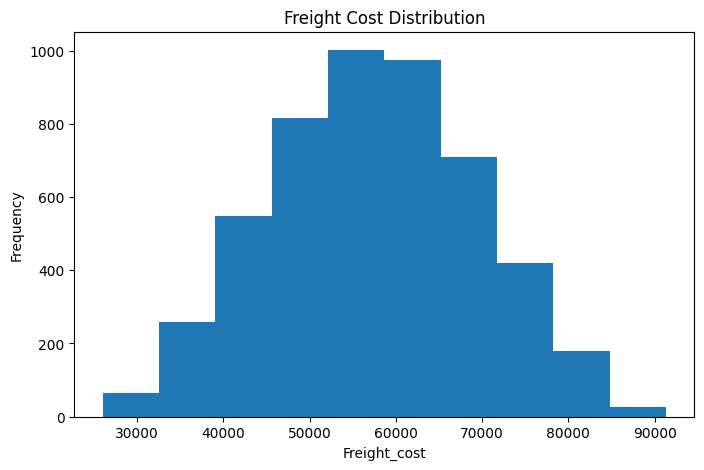

In [ ]:
#Histogram
plt.figure(figsize=(8,5))
plt.hist(df["Freight_Cost"])
plt.title("Freight Cost Distribution")
plt.xlabel("Freight_cost")
plt.ylabel("Frequency")
plt.show()

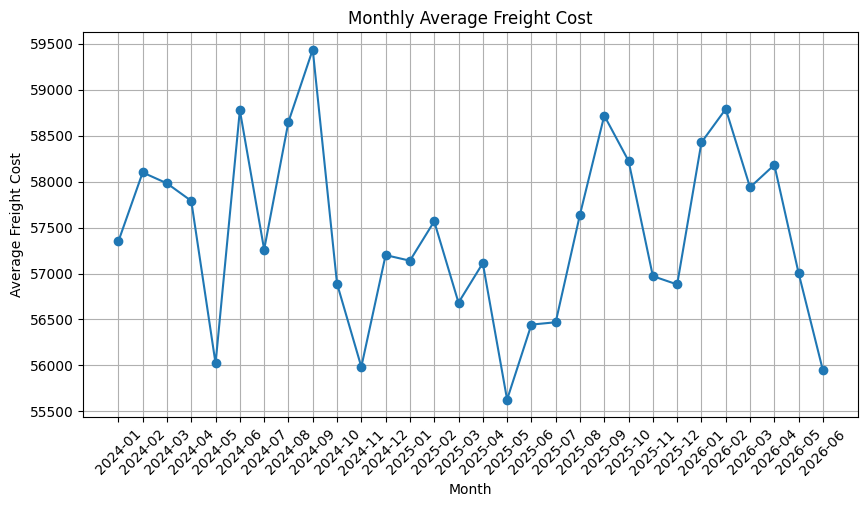

In [ ]:
#Line Chart – Freight Cost Trend))
import pandas as pd
import matplotlib.pyplot as plt
df["Booking_Date"]=pd.to_datetime(df["Booking_Date"])
monthly=df.groupby(df["Booking_Date"].dt.to_period("M"))["Freight_Cost"].mean()
plt.figure(figsize=(10,5))
plt.plot(monthly.index.astype(str),monthly.values,marker="o")
plt.title("Monthly Average Freight Cost")
plt.xlabel("Month")
plt.ylabel("Average Freight Cost")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()



<Figure size 1000x500 with 0 Axes>

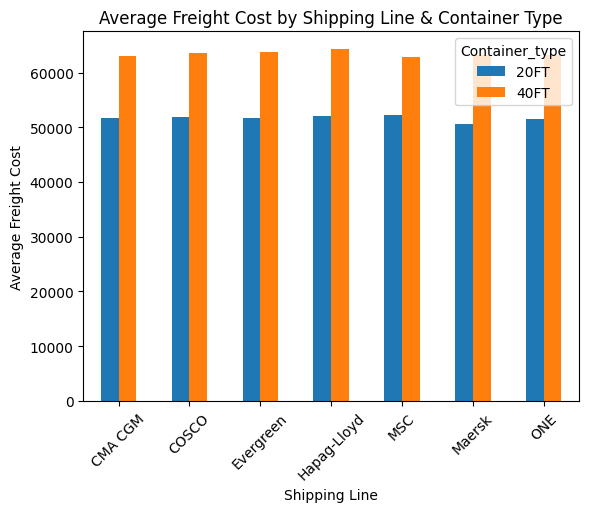

In [ ]:
#Bar Chart – Average Freight Cost by Shipping Line
shipping=df.groupby(["Shipping_Line","Container_Type"])["Freight_Cost"].mean().unstack()
plt.figure(figsize=(10,5))
shipping.plot(kind="bar")
plt.title("Average Freight Cost by Shipping Line & Container Type")
plt.xlabel("Shipping Line")
plt.ylabel("Average Freight Cost")
plt.xticks(rotation=45)
plt.legend(title="Container_type")
plt.show()



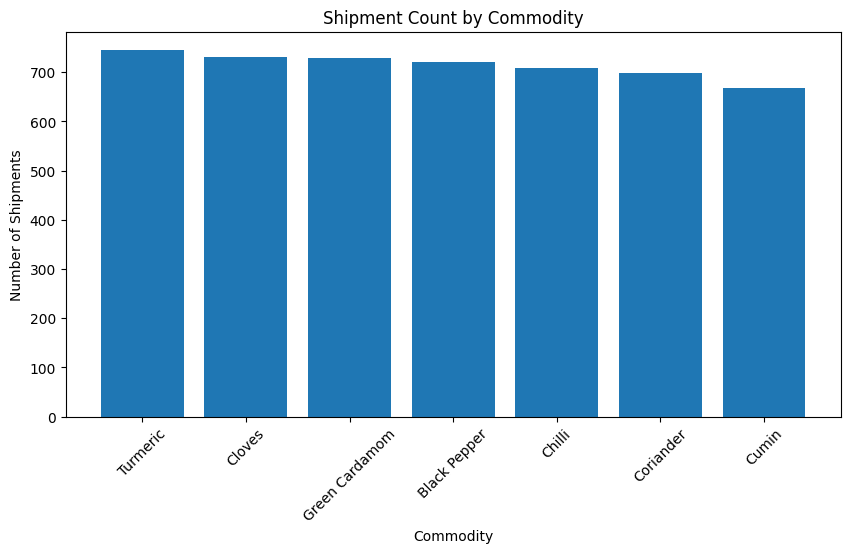

In [ ]:
#Shipment Count by Commodity
Commodity=df["Commodity"].value_counts()
plt.figure(figsize=(10,5))
plt.bar(Commodity.index,Commodity.values)
plt.title("Shipment Count by Commodity")
plt.xlabel("Commodity")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=45)
plt.show()




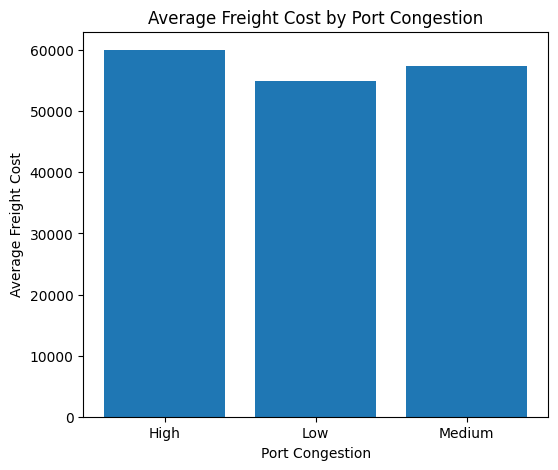

In [ ]:
#Freight Cost by Port Congestion
Congestion=df.groupby('Port_Congestion')['Freight_Cost'].mean()
plt.figure(figsize=( 6,5))
plt.bar(Congestion.index,Congestion.values)
plt.title("Average Freight Cost by Port Congestion")
plt.xlabel("Port Congestion")
plt.ylabel("Average Freight Cost")
plt.show()

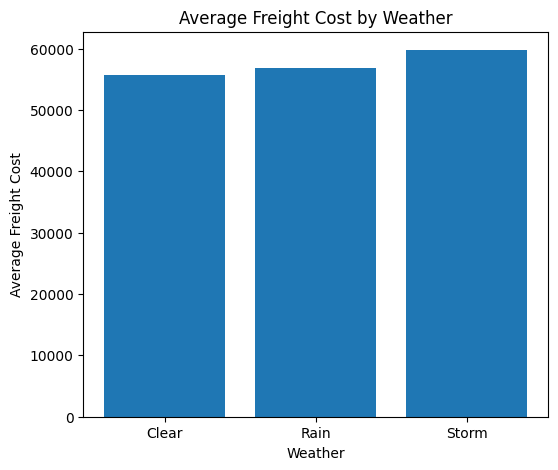

In [ ]:
#Freight Cost by Weather
Weather=df.groupby('Weather')['Freight_Cost'].mean()
plt.figure(figsize=(6,5))
plt.bar(Weather.index,Weather.values)
plt.title("Average Freight Cost by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Freight Cost")
plt.show()

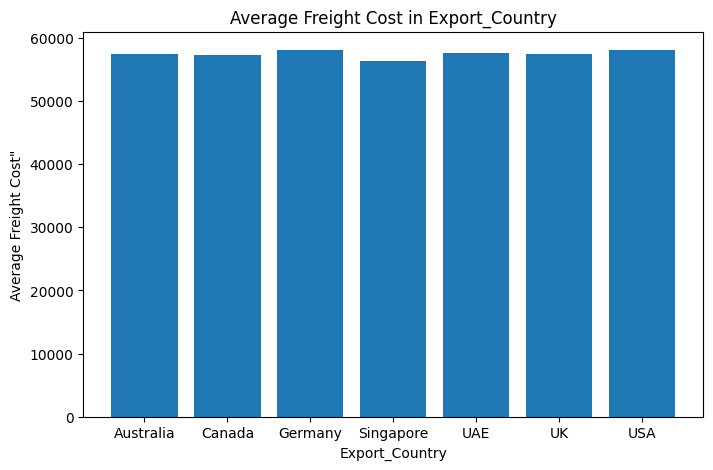

In [ ]:
#Freight Cost by Export Country
Export_Country=df.groupby('Export_Country')['Freight_Cost'].mean()
plt.figure(figsize=(8,5))
plt.bar(Export_Country.index,Export_Country.values)
plt.title("Average Freight Cost in Export_Country")
plt.xlabel('Export_Country')
plt.ylabel('Average Freight Cost"')
plt.show()

In [ ]:
#Select Features (X)
X=df[
[
"Origin",
"Destination",
"Shipping_Line",
"Container_Type",
"Weight_MT",
"Distance_KM",
"Fuel_Price",
"Transit_Days",
"Month"
]
]

In [ ]:
Y=df["Freight_Cost"]

In [ ]:
categorical=[
"Origin",
"Destination",
"Shipping_Line",
"Container_Type"
]

In [ ]:
preprocessor=ColumnTransformer(
[
(
"cat",
OneHotEncoder(handle_unknown="ignore"),
categorical
)
],
remainder="passthrough"
)

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(
X,
Y,
test_size=0.20,
random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
         n_estimators=100,
         random_state=42
    ))
])

In [ ]:
model.fit(
X_train,
Y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Origin', 'Destination',
                                                   'Shipping_Line',
                                                   'Container_Type'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [ ]:
prediction=model.predict(X_test)

In [ ]:
#Compare Actual vs Predicted
result=pd.DataFrame(
{
"Actual":Y_test,
"Predicted":prediction
}
)

result.head(20)

,Actual,Predicted
1501,42598.2,45823.332
2586,43827.2,42189.286
2653,54201.6,57367.776
1055,60368.8,61883.348
705,49677.6,55324.066
106,62065.2,66205.448
589,71343.4,70970.574
2468,54317.8,58101.486
2413,67273.0,69326.166
1600,50965.6,52165.266


In [ ]:
mae = mean_absolute_error(Y_test, prediction)
mse = mean_squared_error(Y_test, prediction)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, prediction)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE : 2196.4234860000006
MSE : 7340543.886221205
RMSE: 2709.3438110031743
R2 Score: 0.946905252424758


In [ ]:
new_data = pd.DataFrame({

    "Shipment_ID": ["SH05001"],
    "Origin": ["Mumbai"],
    "Destination": ["Dubai"],
    "Shipping_Line": ["Maersk"],
    "Container_Type": ["40FT"],
    "Commodity": ["Black Pepper"],
    "Weight_MT": [24],
    "Distance_KM": [2400],
    "Fuel_Price": [95],
    "Transit_Days": [18],
    "Port_Congestion": ["High"],
    "Weather": ["Rain"],
    "Customer": ["Customer_001"],
    "Export_Country": ["UAE"],
    "Exchange_Rate": [84.5],
    "Insurance_Cost": [1800],
    "Handling_Charges": [600],
    "Profit": [7000],
    "Month": [8]

})

freight = model.predict(new_data)

print("Predicted Freight Cost:", freight[0])

Predicted Freight Cost: 77961.204


In [ ]:
import joblib
joblib.dump(
model,
"Freight_Cost_Model.pkl"
)

['Freight_Cost_Model.pkl']